In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np

In [2]:
air = pd.read_csv("data/nan.csv")
air

,MMDDHH,PM10,PM25,O3,NO2,CO,SO2
0,06-01-01,28.0,18.0,0.039,0.009,0.3,0.002
1,06-01-02,19.0,14.0,0.041,0.007,0.3,0.002
2,06-01-03,15.0,13.0,0.043,0.006,0.3,0.002
3,06-01-04,16.0,13.0,0.042,0.006,0.3,0.002
4,06-01-05,14.0,11.0,0.041,0.008,0.3,0.003
5,06-01-06,14.0,10.0,0.040,0.009,0.3,0.003
6,06-01-07,15.0,10.0,0.038,0.014,0.3,0.002
7,06-01-08,20.0,10.0,0.034,0.019,0.3,0.002
8,06-01-09,28.0,15.0,0.032,0.022,0.4,0.003
9,06-01-10,28.0,12.0,0.035,0.017,0.4,0.003


In [3]:
### 결측치 확인-1
air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MMDDHH  24 non-null     object 
 1   PM10    21 non-null     float64
 2   PM25    21 non-null     float64
 3   O3      22 non-null     float64
 4   NO2     22 non-null     float64
 5   CO      22 non-null     float64
 6   SO2     22 non-null     float64
dtypes: float64(6), object(1)
memory usage: 1.4+ KB


In [6]:
### 결측치 확인-2
# air.isnull()
air.isna()

,MMDDHH,PM10,PM25,O3,NO2,CO,SO2
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False


In [5]:
### 결측치 확인-3
air.isnull().sum()

MMDDHH    0
PM10      3
PM25      3
O3        2
NO2       2
CO        2
SO2       2
dtype: int64

In [8]:
# !pip install missingno

<Axes: >

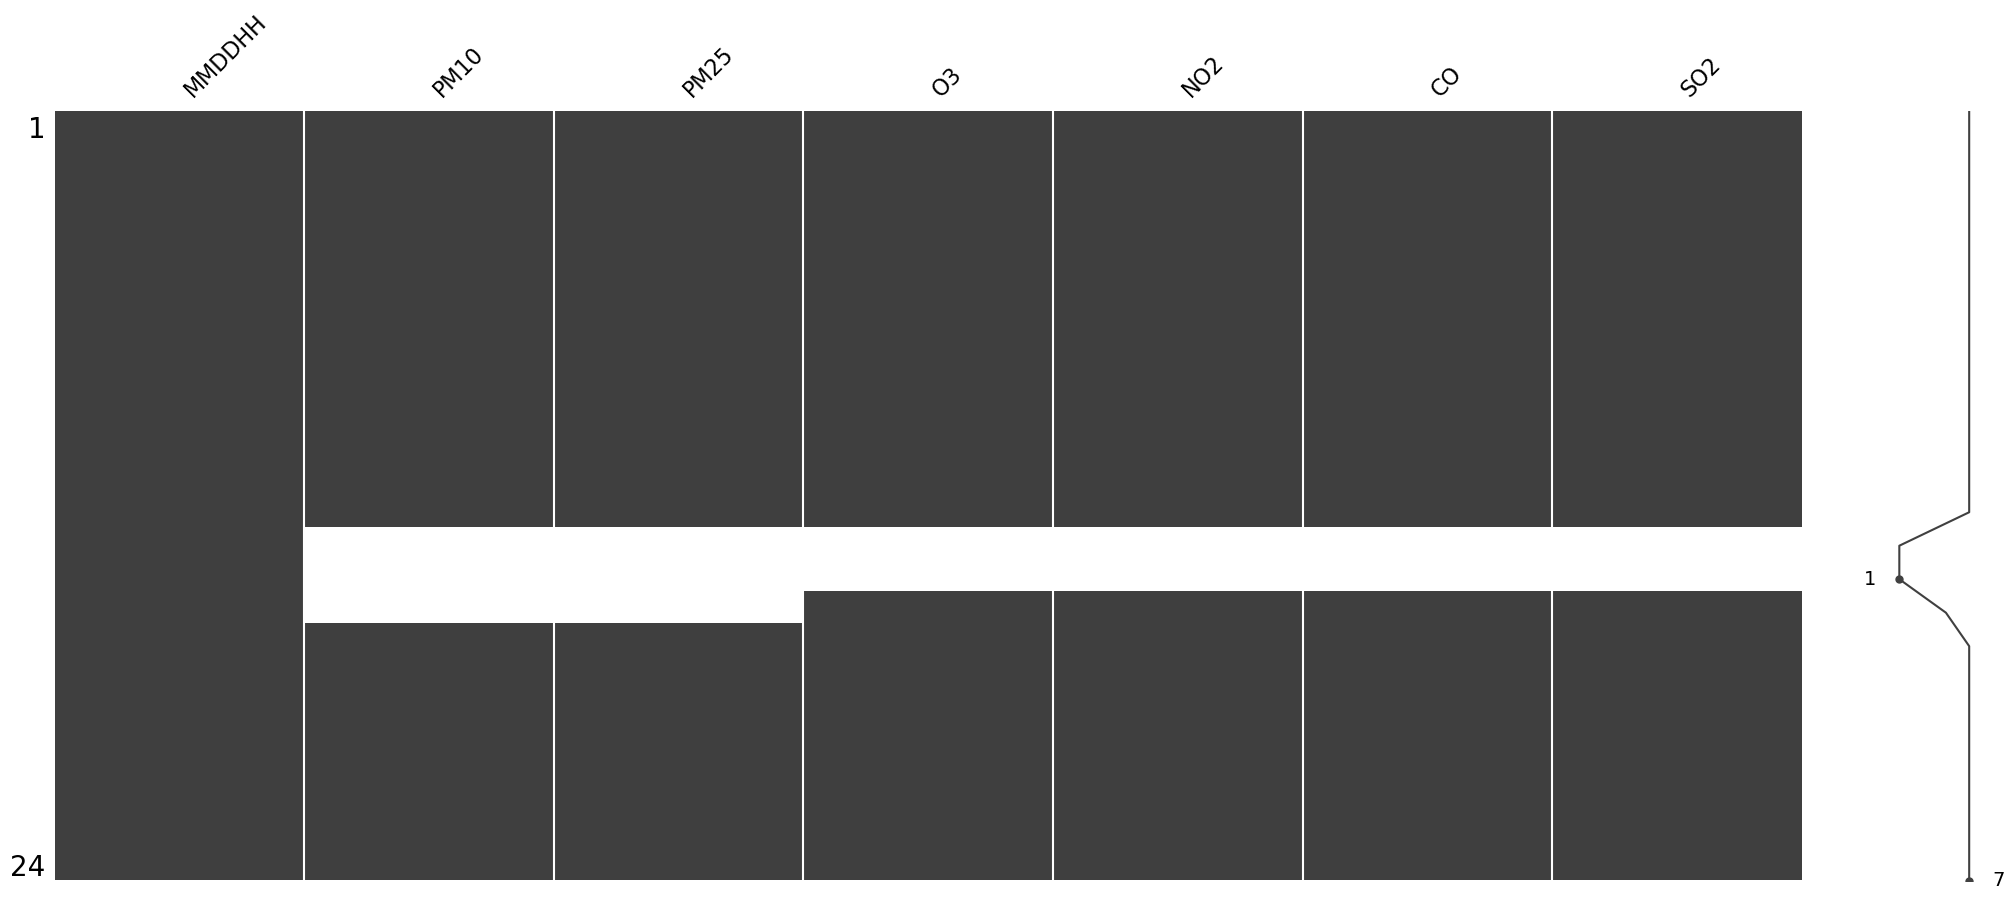

In [9]:
### 결측치 확인-4

import missingno as msno
msno.matrix(air)

<Axes: >

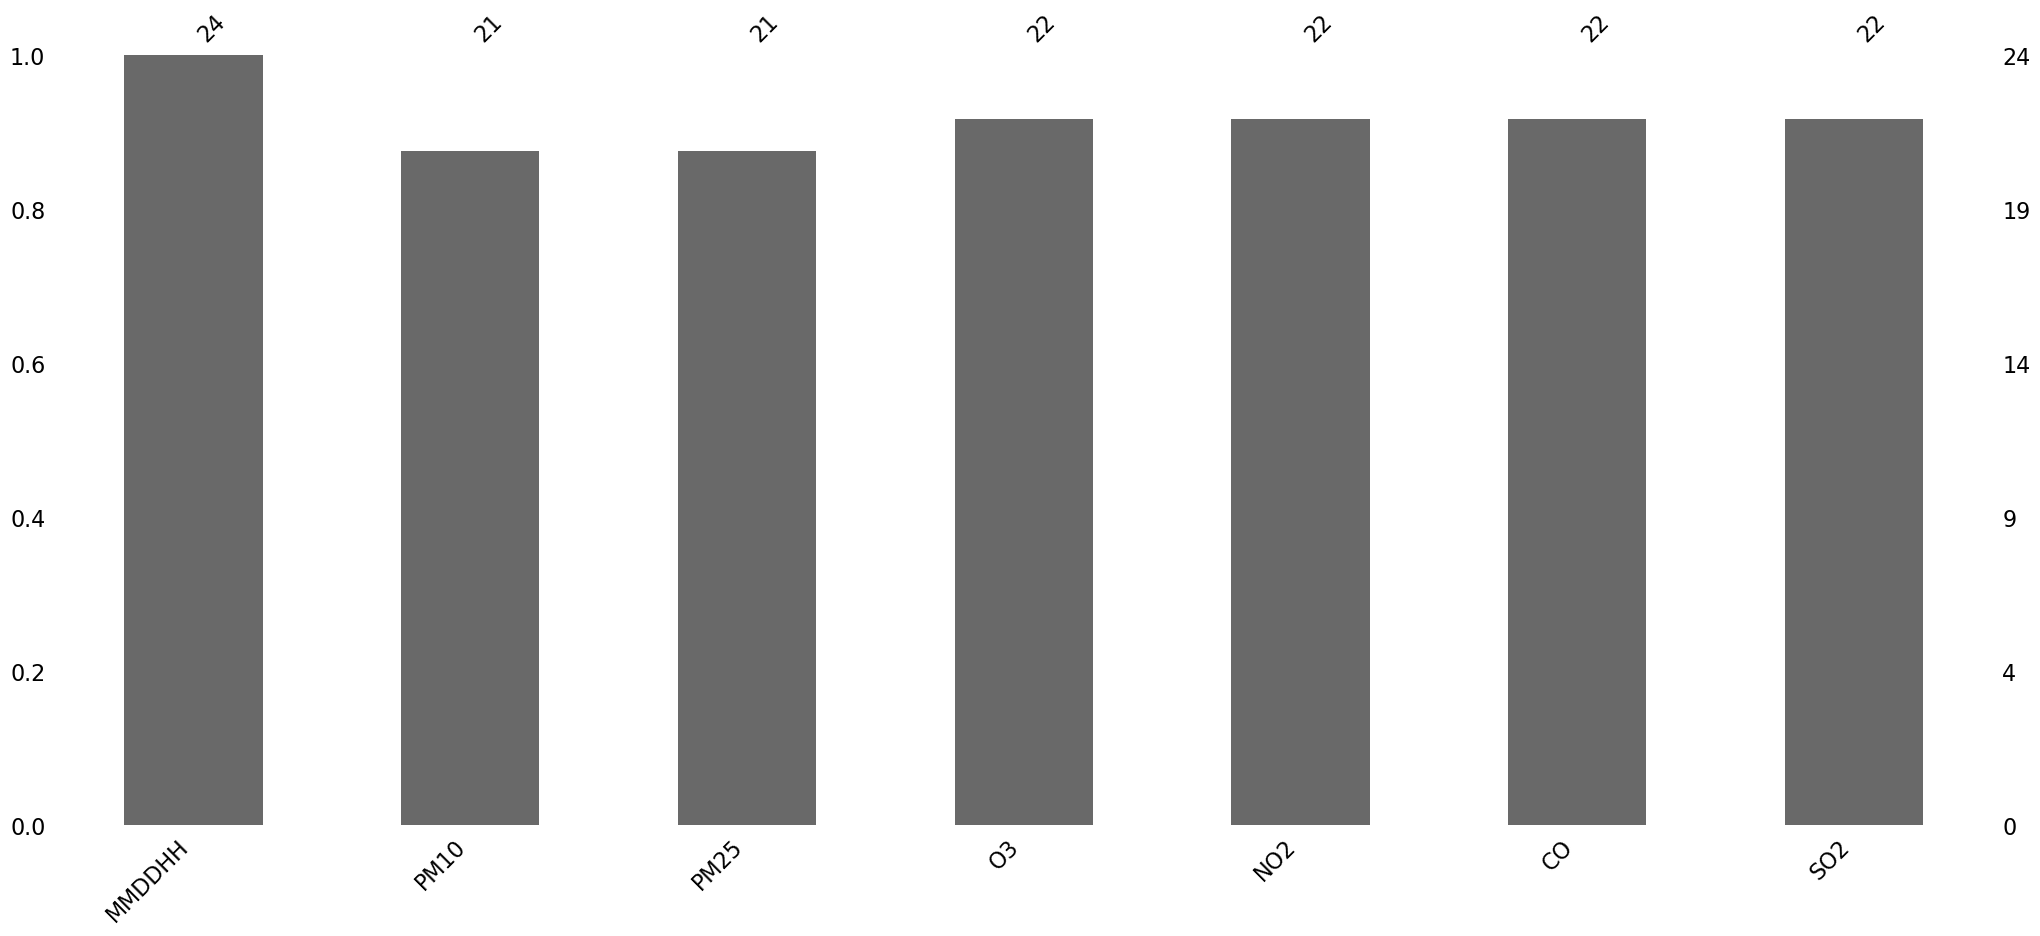

In [10]:
msno.bar(air)

## 결측치 처리_결측치 제거

In [11]:
air_d = air.dropna(axis=0)    ## 결측치가 있는 '행'을 삭제
air_d

,MMDDHH,PM10,PM25,O3,NO2,CO,SO2
0,06-01-01,28.0,18.0,0.039,0.009,0.3,0.002
1,06-01-02,19.0,14.0,0.041,0.007,0.3,0.002
2,06-01-03,15.0,13.0,0.043,0.006,0.3,0.002
3,06-01-04,16.0,13.0,0.042,0.006,0.3,0.002
4,06-01-05,14.0,11.0,0.041,0.008,0.3,0.003
5,06-01-06,14.0,10.0,0.040,0.009,0.3,0.003
6,06-01-07,15.0,10.0,0.038,0.014,0.3,0.002
7,06-01-08,20.0,10.0,0.034,0.019,0.3,0.002
8,06-01-09,28.0,15.0,0.032,0.022,0.4,0.003
9,06-01-10,28.0,12.0,0.035,0.017,0.4,0.003


## 결측치 처리 - 평균값으로 대체

In [12]:
# 먼저, 각 항목의 평균 확인
mean_air = air.mean(numeric_only=True)
mean_air

PM10    23.761905
PM25    12.666667
O3       0.039773
NO2      0.015364
CO       0.350000
SO2      0.002727
dtype: float64

In [13]:
air_m = air.fillna(mean_air)
air_m

,MMDDHH,PM10,PM25,O3,NO2,CO,SO2
0,06-01-01,28.000000,18.000000,0.039000,0.009000,0.30,0.002000
1,06-01-02,19.000000,14.000000,0.041000,0.007000,0.30,0.002000
2,06-01-03,15.000000,13.000000,0.043000,0.006000,0.30,0.002000
3,06-01-04,16.000000,13.000000,0.042000,0.006000,0.30,0.002000
4,06-01-05,14.000000,11.000000,0.041000,0.008000,0.30,0.003000
5,06-01-06,14.000000,10.000000,0.040000,0.009000,0.30,0.003000
6,06-01-07,15.000000,10.000000,0.038000,0.014000,0.30,0.002000
7,06-01-08,20.000000,10.000000,0.034000,0.019000,0.30,0.002000
8,06-01-09,28.000000,15.000000,0.032000,0.022000,0.40,0.003000
9,06-01-10,28.000000,12.000000,0.035000,0.017000,0.40,0.003000


## 결측치 처리 - 중앙값으로 대체

In [14]:
air_md = air.median(numeric_only=True)
air_md = air.fillna(air_md)
air_md

,MMDDHH,PM10,PM25,O3,NO2,CO,SO2
0,06-01-01,28.0,18.0,0.0390,0.0090,0.30,0.002
1,06-01-02,19.0,14.0,0.0410,0.0070,0.30,0.002
2,06-01-03,15.0,13.0,0.0430,0.0060,0.30,0.002
3,06-01-04,16.0,13.0,0.0420,0.0060,0.30,0.002
4,06-01-05,14.0,11.0,0.0410,0.0080,0.30,0.003
5,06-01-06,14.0,10.0,0.0400,0.0090,0.30,0.003
6,06-01-07,15.0,10.0,0.0380,0.0140,0.30,0.002
7,06-01-08,20.0,10.0,0.0340,0.0190,0.30,0.002
8,06-01-09,28.0,15.0,0.0320,0.0220,0.40,0.003
9,06-01-10,28.0,12.0,0.0350,0.0170,0.40,0.003


# 타이타닉 데이터의 결측치 처리

In [15]:
titanic_df= pd.read_csv("data/titanic.csv")
titanic_df.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [16]:
titanic_df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [17]:
## age의 결측치를 평균값으로 채우기

titanic_df['age'] = titanic_df['age'].fillna(titanic_df['age'].mean())
titanic_df['age'].isnull().sum()

np.int64(0)

In [18]:
##  "deck"열 삭제
titanic_df = titanic_df.drop('deck', axis=1)

In [19]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  embark_town  889 non-null    object 
 12  alive        891 non-null    object 
 13  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(6)
memory usage: 85.4+ KB


In [20]:
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [21]:
## embark_town의 결측치를 최빈값으로 채우기

titanic_df['embark_town'][825:830]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
Name: embark_town, dtype: object

In [22]:
### 최빈값 찾기_1
titanic_df['embark_town'].value_counts(dropna=True)

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [23]:
### 최빈값 찾기_2
most_freq = titanic_df['embark_town'].value_counts(dropna=True).idxmax() 
most_freq

'Southampton'

In [24]:
### 최빈값으로 대체
titanic_df['embark_town'] = titanic_df['embark_town'].fillna(most_freq)
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  embark_town  891 non-null    object 
 12  alive        891 non-null    object 
 13  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(6)
memory usage: 85.4+ KB


In [25]:
## embark_town의 결측치를 앞 또는 뒤의 값으로 채우기

titanic_df2 = pd.read_csv("data/titanic.csv")
titanic_df2['embark_town'][825:831]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
830      Cherbourg
Name: embark_town, dtype: object

In [26]:
titanic_df2['embark_town'] = titanic_df2['embark_town'].ffill()
titanic_df2['embark_town'][825:831]

## ffill() : 바로 앞의 데이터 채움
## bfill()  => 바로 뒤의 데이터로 채움

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829     Queenstown
830      Cherbourg
Name: embark_town, dtype: object